## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2022_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-01,2022,1,2021-12-31,37.991999,23.654887,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,2022-01-01,37.991999,23.654887,14226.0,14165.0,37.991999,23.654887,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,2022-01-01,37.950174,23.650108,0.130592,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.130592,0.130592
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-16,2022,1,2022-01-15,37.991999,23.654887,0.096758,0.002547,-0.134993,-0.002547,0.187609,0.061188,-0.196106,-0.061188,0.118994,0.064595,0.091346,0.064595,2022-01-16,37.991999,23.654887,14287.0,13866.0,37.991999,23.654887,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,2022-01-16,37.950174,23.650108,159.481701,2022-01-09,2022-01-02,2022-01-09,2022-01-02,78.943867,159.351109
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-01,2022,1,2021-12-31,38.009965,23.825567,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,2022-01-01,38.009965,23.825567,14321.0,14100.0,38.009965,23.825567,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,2022-01-01,38.050174,23.850109,0.062748,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.062748,0.062748
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-16,2022,1,2022-01-15,38.009965,23.825567,0.147814,0.072285,-0.136770,-0.072285,0.161369,0.079583,-0.143985,-0.079583,0.016419,0.017736,0.010888,0.017736,2022-01-16,38.009965,23.825567,14018.0,13834.0,38.009965,23.825567,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,2022-01-16,38.050174,23.850109,79.632325,2022-01-09,2022-01-02,2022-01-09,2022-01-02,46.362894,79.569577
4,αγιου δημητριου,αττικης,23.73031,37.93357,2022-01-01,2022,1,2021-12-31,37.933609,23.731244,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,2022-01-01,37.933609,23.731244,14206.0,14139.0,37.933609,23.731244,14200.181818,13948.187500,14414.100,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,2022-01-01,37.950174,23.750109,0.160617,2021-12-25,2021-12-18,2022-12-16,2022-12-16,0.160617,0.160617


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-01,2022,1,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.0,14165.0,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2022-01-16,2022,1,0.096758,0.002547,-0.134993,-0.002547,0.187609,0.061188,-0.196106,-0.061188,0.118994,0.064595,0.091346,0.064595,14287.0,13866.0,14199.125000,13934.842105,14363.375,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,159.481701,78.943867,159.351109
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-01,2022,1,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.0,14100.0,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2022-01-16,2022,1,0.147814,0.072285,-0.136770,-0.072285,0.161369,0.079583,-0.143985,-0.079583,0.016419,0.017736,0.010888,0.017736,14018.0,13834.0,14099.818182,13918.117647,14384.600,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,79.632325,46.362894,79.569577
4,αγιου δημητριου,αττικης,23.73031,37.93357,2022-01-01,2022,1,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.0,14139.0,14200.181818,13948.187500,14414.100,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2022-01-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2022.0,1.0,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,14226.000000,14165.000000,14199.125000,13934.842105,14363.375000,14040.000000,14448.500000,13892.333333,14987.882353,14376.933333,0.130592,0.130592,0.130592
1,2022-01-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2022.0,1.0,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,14321.000000,14100.000000,14099.818182,13918.117647,14384.600000,13979.454545,14386.545455,13868.857143,14889.950000,14329.600000,0.062748,0.062748,0.062748
2,2022-01-01,αγιου δημητριου,αττικης,23.730310,37.933570,2022.0,1.0,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,14206.000000,14139.000000,14200.181818,13948.187500,14414.100000,14067.875000,14502.222222,13931.266667,14961.550000,14371.277778,0.160617,0.160617,0.160617
3,2022-01-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2022.0,1.0,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,14199.000000,14119.000000,14190.625000,13901.705882,14401.750000,13960.200000,14454.111111,13833.666667,15002.235294,14317.058824,0.170459,0.170459,0.170459
4,2022-01-01,αγκιστριου,αττικης,23.340090,37.695030,2022.0,1.0,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14439.000000,14284.000000,14257.210526,14079.428571,14341.461538,14109.933333,14310.692308,14083.846154,14608.150000,14369.600000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,2022-12-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2022.0,12.0,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,14388.000000,14246.000000,14126.733333,13924.937500,14387.636364,13976.357143,14458.777778,13907.812500,14918.823529,14314.857143,878.533587,64.381842,66.835793
1580,2022-12-16,φυλης,αττικης,23.688620,38.106703,2022.0,12.0,0.216847,0.110849,-0.152700,-0.110849,0.226193,0.088282,-0.180252,-0.088282,0.052931,0.038263,0.061033,0.038263,14316.666667,13979.000000,14073.853817,13832.119048,14245.753302,13860.322611,14232.629759,13766.500000,14818.647475,14186.453276,829.531002,37.073307,38.705631
1581,2022-12-16,χαλανδριου,αττικης,23.809410,38.022260,2022.0,12.0,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,14403.000000,14164.000000,14091.900000,13949.066667,14388.250000,13990.642857,14367.100000,13856.142857,14917.647059,14351.625000,930.487912,72.550454,75.314096
1582,2022-12-16,χαϊδαριου,αττικης,23.630840,38.009420,2022.0,12.0,0.320253,0.268085,-0.157603,-0.268085,0.343233,0.240475,-0.205532,-0.240475,0.048015,0.063077,0.058487,0.063077,14339.000000,14122.000000,14190.052632,13901.263158,14320.923077,13998.000000,14417.083333,13866.933333,14846.409091,14306.055556,839.945864,58.605859,61.133574


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [15]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [16]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [17]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [18]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [19]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

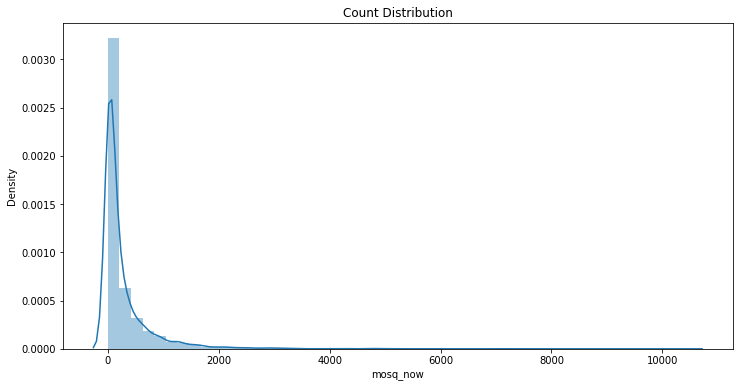

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [21]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

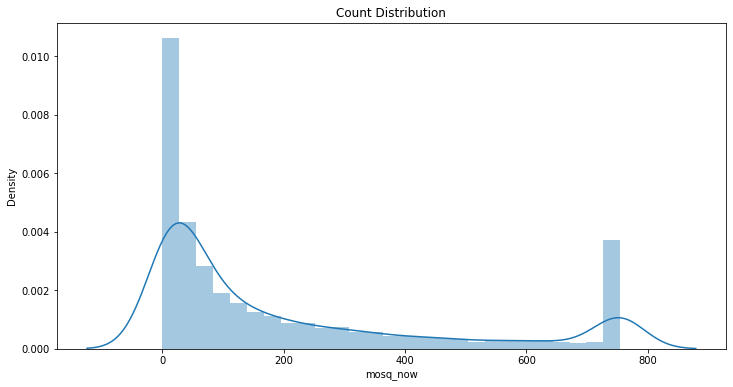

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

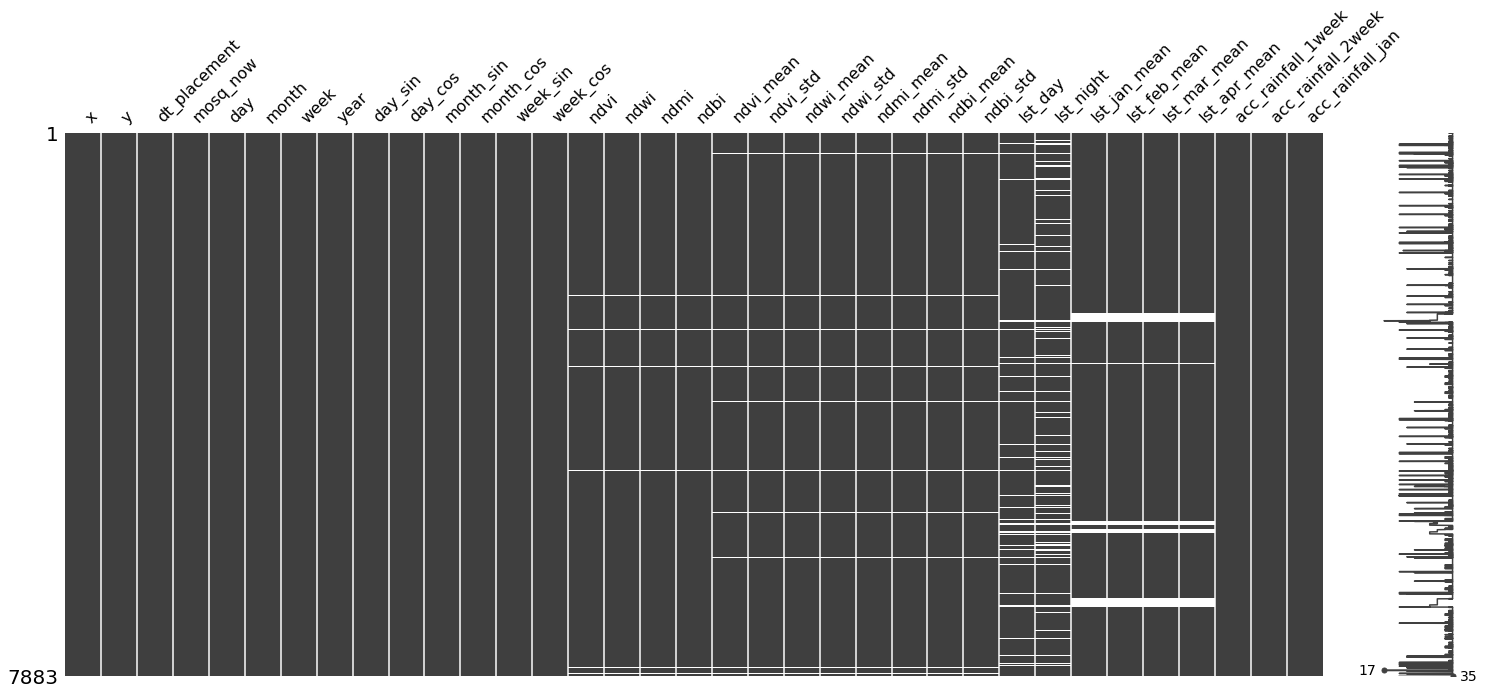

In [23]:
missingno.matrix(mosquito_data_nuts2)

In [24]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [25]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

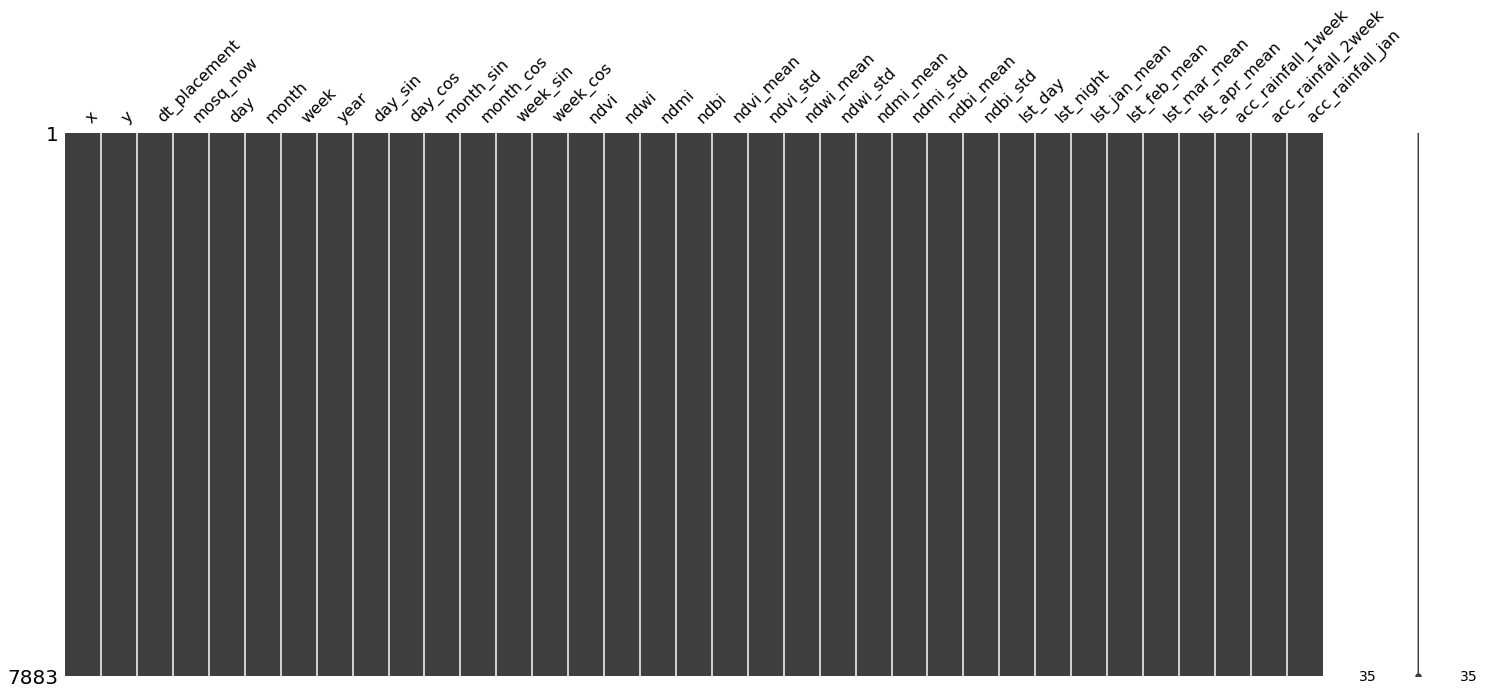

In [26]:
missingno.matrix(mosquito_data_nuts2)

In [27]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [28]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [29]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 21.15614 | Val Loss: 23.81495 | Train Acc: 2.929| Val Acc: 2.345
Epoch 002: | Train Loss: 18.32563 | Val Loss: 26.64944 | Train Acc: 2.223| Val Acc: 2.115
Epoch 003: | Train Loss: 18.92751 | Val Loss: 23.81985 | Train Acc: 2.309| Val Acc: 2.032
Epoch 004: | Train Loss: 18.17224 | Val Loss: 25.55833 | Train Acc: 2.144| Val Acc: 2.037
Epoch 005: | Train Loss: 18.05836 | Val Loss: 23.33890 | Train Acc: 2.120| Val Acc: 2.004
Epoch 006: | Train Loss: 17.70585 | Val Loss: 23.81349 | Train Acc: 2.092| Val Acc: 2.104
Epoch 007: | Train Loss: 17.14296 | Val Loss: 23.82236 | Train Acc: 2.007| Val Acc: 1.965
Epoch 008: | Train Loss: 17.37688 | Val Loss: 23.56413 | Train Acc: 2.019| Val Acc: 2.039
Epoch 009: | Train Loss: 16.84354 | Val Loss: 23.89359 | Train Acc: 1.984| Val Acc: 2.021
Epoch 010: | Train Loss: 16.83081 | Val Loss: 23.73466 | Train Acc: 1.985| Val Acc: 2.047
Epoch 011: | Train Loss: 16.90391 | Val Loss: 23.72785 | Train Acc: 1.982| Val Acc: 2.015
Epoch 012:

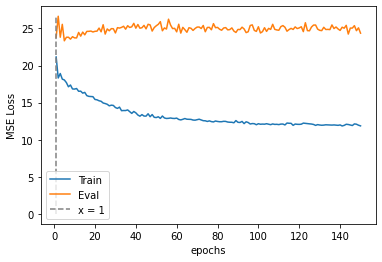

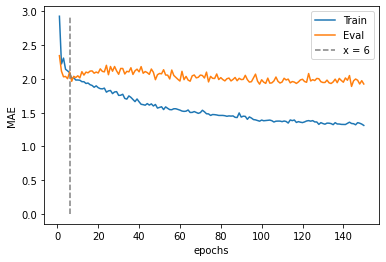

In [30]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [31]:
metrics(train, test, threshold=30)

MAE on train set:  152.6989622596166
min prediction: 1
max prediction: 814

MAE on test set:  147.96807141391565
Error ⩽ 30: 19.56 %
min prediction: 1
max prediction: 851


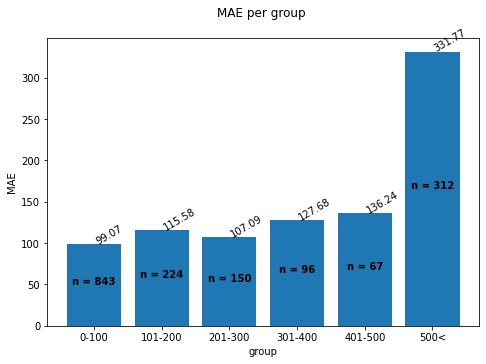

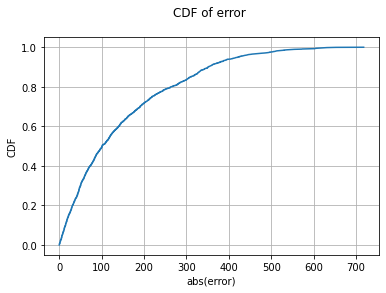

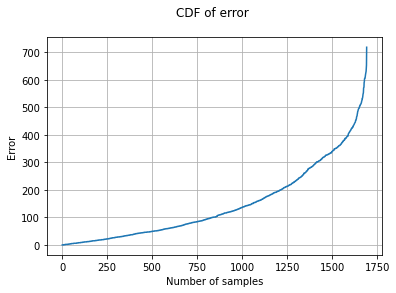

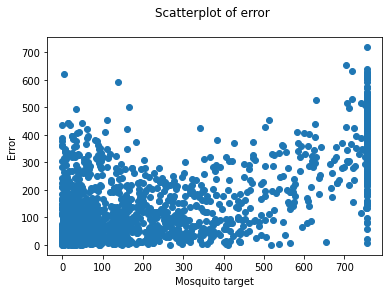

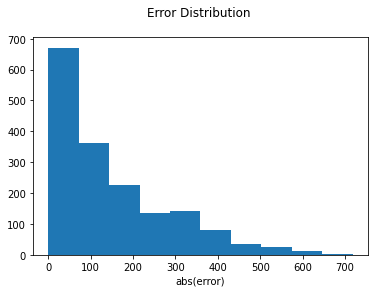

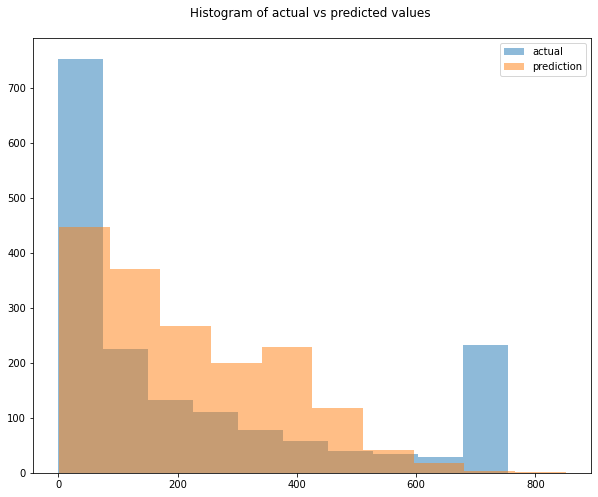

In [32]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.74644 | Val Loss: 2.41692 | Train Acc: 1.568| Val Acc: 1.633
Epoch 002: | Train Loss: 13.90395 | Val Loss: 1.89628 | Train Acc: 1.570| Val Acc: 1.633
Epoch 003: | Train Loss: 13.37863 | Val Loss: 1.94344 | Train Acc: 1.505| Val Acc: 1.633
Epoch 004: | Train Loss: 13.49476 | Val Loss: 1.55536 | Train Acc: 1.527| Val Acc: 1.633
Epoch 005: | Train Loss: 13.26615 | Val Loss: 2.44530 | Train Acc: 1.493| Val Acc: 1.633
Epoch 006: | Train Loss: 12.95752 | Val Loss: 1.79478 | Train Acc: 1.467| Val Acc: 1.633
Epoch 007: | Train Loss: 12.92423 | Val Loss: 1.47899 | Train Acc: 1.456| Val Acc: 1.633
Epoch 008: | Train Loss: 13.06159 | Val Loss: 0.78292 | Train Acc: 1.469| Val Acc: 0.633
Epoch 009: | Train Loss: 12.83940 | Val Loss: 0.88769 | Train Acc: 1.446| Val Acc: 0.633
Epoch 010: | Train Loss: 12.77288 | Val Loss: 1.41131 | Train Acc: 1.434| Val Acc: 1.633
Epoch 011: | Train Loss: 12.90316 | Val Loss: 0.63069 | Train Acc: 1.464| Val Acc: 0.633
Epoch 012: | Train Lo

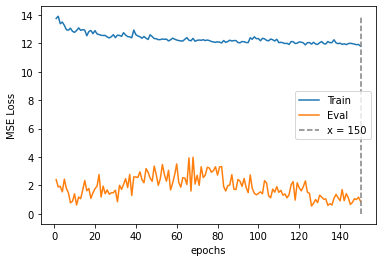

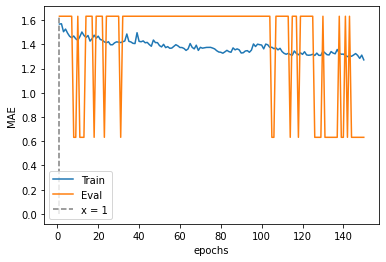

In [33]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [34]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [35]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [36]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [37]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [38]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [39]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

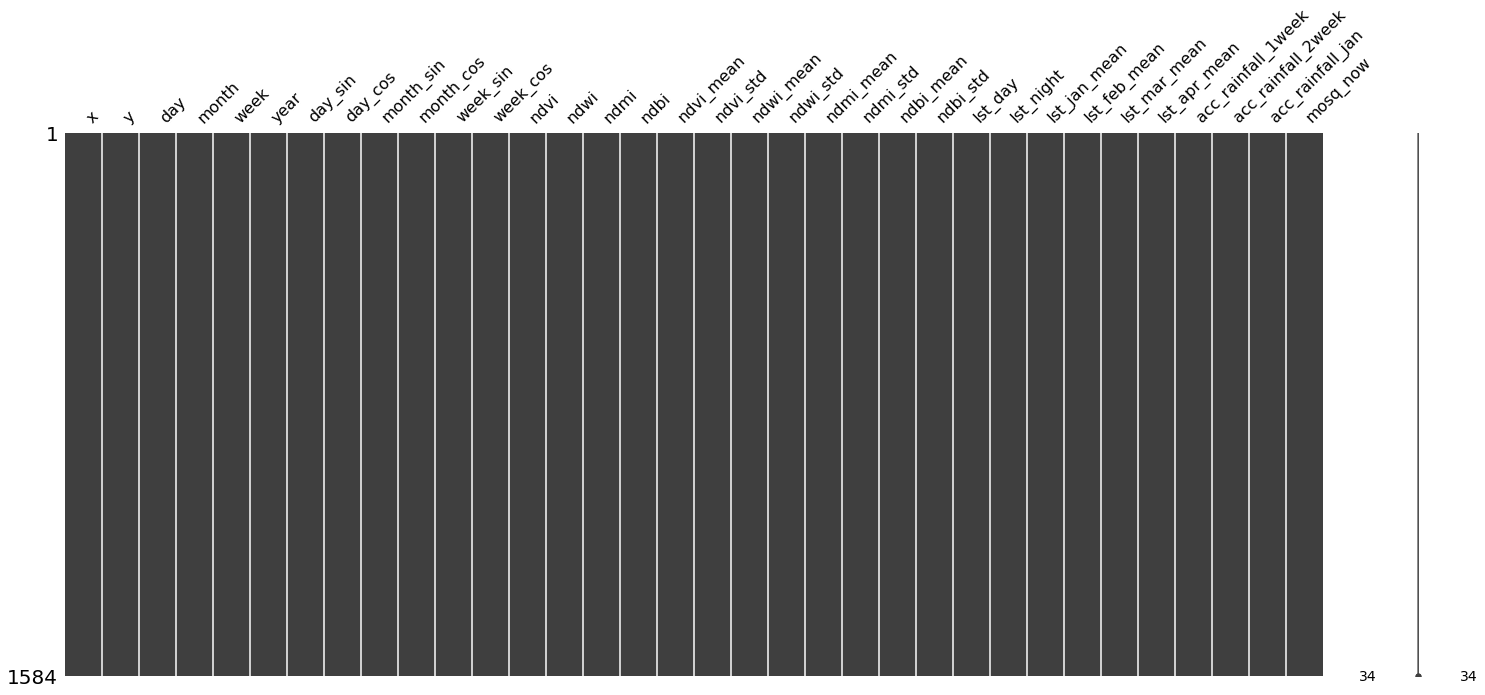

In [40]:
missingno.matrix(dataset_mamoth)

In [41]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [42]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [43]:
predictions = give_predictions(model, dataset_mamoth)

In [44]:
mosqutio_predictions['mosq_pred'] = predictions

In [45]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2022-01-01,43
1,23.826420,38.008060,2022-01-01,31
2,23.730310,37.933570,2022-01-01,38
3,23.713410,38.047210,2022-01-01,38
4,23.340090,37.695030,2022-01-01,36
...,...,...,...,...
1579,23.776280,38.014770,2022-12-16,1
1580,23.688620,38.106703,2022-12-16,1
1581,23.809410,38.022260,2022-12-16,1
1582,23.630840,38.009420,2022-12-16,1


In [46]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2022.csv', index = False)